# Part 3: Gradient Signal & Parameter Tuning

**Goal:** Investigate why attention entropy stays constant, diagnose the root cause, and learn which parameters control gradient flow.

---

## 3.1 The Mystery of Frozen Entropy

In Part 2, we fixed the broadcasting bug and softmax is now correct. But something strange happens during training:
- Loss decreases (good!)
- But attention entropy stays nearly constant (suspicious...)

The model seems to be learning *something* (loss goes down), but the attention mechanism isn't learning to **focus**. The attention distribution stays uniform throughout training.

**What's going on?** Let's investigate systematically.

### Load functions

In [24]:
import numpy as np
import matplotlib.pyplot as plt


def generate_argmax_sample(dim=4, value_range=(0, 10), seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.random.randint(value_range[0], value_range[1], size=(dim,))
    return x, np.full((dim,), np.max(x))


def row_softmax(scores: np.ndarray) -> np.ndarray:
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=False, softmax_fn=None):
    if softmax_fn is None:
        softmax_fn = row_softmax
    d_k = W_Q.shape[1]
    Q, K, V = hidden_layer @ W_Q, hidden_layer @ W_K, hidden_layer @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    A = softmax_fn(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    return H, {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}


def mse(pred, target):
    return np.mean((pred - target) ** 2)


def attention_step(W_Q, W_K, W_V, W_H, hidden_layer, target, lr=1e-3, clip=1.0, softmax_fn=None):
    pred, cache = attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=True, softmax_fn=softmax_fn)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)

    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T
    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))

    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)
    dW_Q, dW_K, dW_V = hidden_layer.T @ dQ, hidden_layer.T @ dK, hidden_layer.T @ dV

    grad_norms = {"W_Q": float(np.linalg.norm(dW_Q)), "W_K": float(np.linalg.norm(dW_K)),
                  "W_V": float(np.linalg.norm(dW_V)), "W_H": float(np.linalg.norm(dW_H))}

    dW_Q, dW_K = np.clip(dW_Q, -clip, clip), np.clip(dW_K, -clip, clip)
    dW_V, dW_H = np.clip(dW_V, -clip, clip), np.clip(dW_H, -clip, clip)

    return W_Q - lr*dW_Q, W_K - lr*dW_K, W_V - lr*dW_V, W_H - lr*dW_H, loss, cache, grad_norms


def make_hidden_and_target(x_raw, y_raw, W_embed, scale=10.0):
    x = (np.array(x_raw, dtype=np.float64).reshape(-1, 1)) / scale
    y = (np.array(y_raw, dtype=np.float64).reshape(-1, 1)) / scale
    return x @ W_embed, y @ W_embed


def decode_embedding_to_scalar(embedded, W_embed, scale=10.0):
    w = W_embed.reshape(-1)
    return (embedded @ w) / (w @ w + 1e-12) * scale


def attention_row_entropy(A: np.ndarray) -> float:
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    return float(np.mean(-np.sum(P * np.log(P), axis=1)))


def attention_row_entropy_normalized(A: np.ndarray) -> float:
    """Normalized mean row entropy in [0,1]. 0=sharp, 1=uniform."""
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    P = P / np.sum(P, axis=1, keepdims=True)
    H = -np.sum(P * np.log(P), axis=1)
    return float(np.mean(H / (np.log(P.shape[1]) + eps)))


def attention_diagnostics(alpha, logits, alpha_prev=None, V=None):
    """Per-sample diagnostics: entropy, sharpness, logit scale, gradient flow health."""
    eps = 1e-9
    row_entropy = -np.sum(alpha * np.log(alpha + eps), axis=-1)
    max_weights = np.max(alpha, axis=-1)
    support = 1.0 / (np.sum(alpha**2, axis=-1) + eps)       # effective support (1=one-hot, n=uniform)
    sensitivity = alpha * (1 - alpha)                         # α(1-α): softmax Jacobian diagonal

    movement = None
    if alpha_prev is not None and alpha.shape == alpha_prev.shape:
        movement = np.linalg.norm(alpha - alpha_prev, 'fro')

    return {
        "entropy_mean": float(np.mean(row_entropy)),
        "entropy_std": float(np.std(row_entropy)),
        "entropy_min": float(np.min(row_entropy)),
        "max_mean": float(np.mean(max_weights)),
        "max_std": float(np.std(max_weights)),
        "max_weights": max_weights.flatten(),
        "support_mean": float(np.mean(support)),
        "support_std": float(np.std(support)),
        "support_all": support.flatten(),
        "sensitivity_mean": float(np.mean(sensitivity)),
        "sensitivity_max": float(np.max(sensitivity)),
        "logit_abs_mean": float(np.mean(np.abs(logits))),
        "logit_max": float(np.max(np.abs(logits))),
        "logit_std": float(np.std(logits)),
        "movement": movement,
        "output_norm": float(np.linalg.norm(alpha @ V)) if V is not None else None,
        "alpha_flat": alpha.flatten(),
    }


# ============================================================
# Training loop (reusable across all sections)
# ============================================================

def train_attention_model(
    train_set, d_model=8, init_scale=0.1, scale=10.0, lr=1e-3, clip=1.0,
    epochs=5000, seed_embed=7, seed_weights=7, verbose=True,
    track_diagnostics=False, diagnostic_freq=100,
):
    """Train attention on argmax task. Returns dict with histories + weights."""
    rng_embed = np.random.default_rng(seed_embed)
    W_embed = init_scale * rng_embed.standard_normal((1, d_model))

    rng_w = np.random.default_rng(seed_weights)
    wq = init_scale * rng_w.standard_normal((d_model, d_model))
    wk = init_scale * rng_w.standard_normal((d_model, d_model))
    wv = init_scale * rng_w.standard_normal((d_model, d_model))
    wh = init_scale * rng_w.standard_normal((d_model, d_model))

    loss_hist, entropy_hist = [], []
    grad_hist = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

    # Diagnostics storage (populated only when track_diagnostics=True)
    diag_keys = ["entropy_mean", "entropy_std", "entropy_min", "max_mean", "max_std",
                 "support_mean", "support_std", "sensitivity_mean",
                 "logit_abs_mean", "logit_max", "logit_std", "movement", "output_norm"]
    diagnostics = {"epochs": [], **{k: [] for k in diag_keys},
                   "grad_relative": {"W_Q": [], "W_K": [], "W_V": [], "W_H": []},
                   "alpha_snapshots": [], "max_weights_snapshots": [], "support_snapshots": []}

    prev_alpha = None

    for ep in range(epochs):
        ep_losses, ep_ent, ep_g = [], [], {k: [] for k in grad_hist}
        ep_diag = []

        for x_raw, y_raw in train_set:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale)
            wq, wk, wv, wh, loss, cache, gnorms = attention_step(
                wq, wk, wv, wh, hidden, target, lr=lr, clip=clip)
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_ent.append(attention_row_entropy_normalized(cache["A"]))
                for k in ep_g:
                    ep_g[k].append(gnorms[k])
                if track_diagnostics:
                    ep_diag.append(attention_diagnostics(
                        cache["A"], cache["scores"], alpha_prev=prev_alpha, V=cache["V"]))
                    prev_alpha = cache["A"].copy()

        loss_hist.append(np.mean(ep_losses))
        entropy_hist.append(np.mean(ep_ent))
        for k in grad_hist:
            grad_hist[k].append(np.mean(ep_g[k]))

        if track_diagnostics and ep_diag:
            diagnostics["epochs"].append(ep)
            for dk in diag_keys:
                vals = [d[dk] for d in ep_diag if d[dk] is not None]
                diagnostics[dk].append(np.mean(vals) if vals else 0.0)
            for k in ["W_Q", "W_K", "W_V", "W_H"]:
                w_norm = np.linalg.norm({"W_Q": wq, "W_K": wk, "W_V": wv, "W_H": wh}[k])
                diagnostics["grad_relative"][k].append(grad_hist[k][-1] / (w_norm + 1e-12))
            if ep % diagnostic_freq == 0 or ep == epochs - 1:
                diagnostics["alpha_snapshots"].append((ep, np.concatenate([d["alpha_flat"] for d in ep_diag])))
                diagnostics["max_weights_snapshots"].append((ep, np.concatenate([d["max_weights"] for d in ep_diag])))
                diagnostics["support_snapshots"].append((ep, np.concatenate([d["support_all"] for d in ep_diag])))

        if verbose and (ep + 1) % 1000 == 0:
            print(f"  Epoch {ep+1:5d}: loss={loss_hist[-1]:.6f}, entropy={entropy_hist[-1]:.4f}")

    return {
        "loss": loss_hist, "entropy": entropy_hist, "grad": grad_hist,
        "diagnostics": diagnostics if track_diagnostics else None,
        "cfg": {"scale": scale, "lr": lr, "clip": clip, "init_scale": init_scale, "epochs": epochs},
        "W_embed": W_embed,
        "weights": {"W_Q": wq, "W_K": wk, "W_V": wv, "W_H": wh},
    }


# ============================================================
# Forward-pass helper (avoids repeated weight extraction everywhere)
# ============================================================

def forward_from_result(result, x_raw, y_raw):
    """Run forward pass using a trained result dict. Returns pred, cache, y_decoded."""
    cfg = result["cfg"]
    W_embed = result["W_embed"]
    w = result["weights"]
    hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=cfg["scale"])
    pred, cache = attention_forward(hidden, w["W_Q"], w["W_K"], w["W_V"], w["W_H"], return_cache=True)
    y_decoded = decode_embedding_to_scalar(pred, W_embed, scale=cfg["scale"])
    return pred, cache, y_decoded


def evaluate_model(result, test_set):
    """Test-set evaluation: loss, entropy, accuracy, attention-on-max."""
    test_losses, test_ent, attn_on_max = [], [], []
    correct = 0
    for x_raw, y_raw in test_set:
        pred, cache, y_dec = forward_from_result(result, x_raw, y_raw)
        test_losses.append(mse(pred, make_hidden_and_target(x_raw, y_raw, result["W_embed"], scale=result["cfg"]["scale"])[1]))
        test_ent.append(attention_row_entropy_normalized(cache["A"]))
        true_max = np.argmax(x_raw)
        if np.argmax(y_dec) == true_max:
            correct += 1
        attn_on_max.append(np.mean(cache["A"][:, true_max]))
    return {"test_loss": float(np.mean(test_losses)), "test_entropy": float(np.mean(test_ent)),
            "accuracy": correct / len(test_set), "attention_on_max": float(np.mean(attn_on_max))}


# ============================================================
# Plotting helpers (eliminate repeated plotting code)
# ============================================================

# Shared style for the two configs
STYLES = {
    "default (scale=10, lr=1e-3)": {"color": "tab:red",  "ls": "--", "label": "Default"},
    "boosted (scale=1, lr=1e-2)":  {"color": "tab:blue", "ls": "-",  "label": "Boosted"},
}
GRAD_COLORS = {"W_Q": "tab:blue", "W_K": "tab:orange", "W_V": "tab:green", "W_H": "tab:purple"}


def plot_curves(results, keys, titles, ylabels, yscale="linear", figsize=(14, 4)):
    """Plot 1-row of time-series subplots, one line per config."""
    fig, axes = plt.subplots(1, len(keys), figsize=figsize)
    if len(keys) == 1:
        axes = [axes]
    for ax, key, title, ylabel in zip(axes, keys, titles, ylabels):
        for name, res in results.items():
            s = STYLES[name]
            ax.plot(res[key], s["ls"], color=s["color"], linewidth=2.5, label=s["label"])
        if yscale == "log":
            ax.set_yscale("log")
        ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()


def plot_diagnostic_comparison(results, metric_configs):
    """
    Plot diagnostic time-series. metric_configs is a list of
    (diag_key, title, ylabel, hlines) where hlines is [(y, color, label), ...].
    """
    n = len(metric_configs)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows))
    axes = np.atleast_2d(axes)

    for idx, (dkey, title, ylabel, hlines) in enumerate(metric_configs):
        ax = axes[idx // cols, idx % cols]
        for name, res in results.items():
            diag = res["diagnostics"]
            if not diag:
                continue
            s = STYLES[name]
            epochs = diag["epochs"]
            data = diag[dkey]
            # movement starts at epoch 1
            if dkey == "movement":
                ax.plot(epochs[1:], data[1:], s["ls"], color=s["color"], linewidth=2, label=s["label"])
            else:
                ax.plot(epochs, data, s["ls"], color=s["color"], linewidth=2, label=s["label"])
        for y, c, lbl in hlines:
            ax.axhline(y=y, color=c, linestyle=":", alpha=0.7, label=lbl)
        ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Hide unused axes
    for idx in range(n, rows * cols):
        axes[idx // cols, idx % cols].set_visible(False)
    plt.tight_layout(); plt.show()


def plot_histograms_comparison(results, figsize=(14, 12)):
    """Side-by-side before/after histograms for each config."""
    config_names = list(results.keys())
    fig, axes = plt.subplots(3, len(config_names), figsize=figsize)

    for col, name in enumerate(config_names):
        diag = results[name]["diagnostics"]
        if not diag or len(diag["alpha_snapshots"]) < 2:
            continue
        s = STYLES[name]

        snap_pairs = [("alpha_snapshots", "Attention weight α", "Attention Distribution", None),
                      ("max_weights_snapshots", "Max attention per row", "Max Attention (→1 sharp)", 1.0),
                      ("support_snapshots", "Effective support (# positions)", "Eff. Support (→1 sharp)", 1.0)]

        for row, (snap_key, xlabel, title, vline) in enumerate(snap_pairs):
            ep0, data0 = diag[snap_key][0]
            epN, dataN = diag[snap_key][-1]
            ax = axes[row, col]
            ax.hist(data0, bins=40, alpha=0.4, color="gray", label=f"Epoch {ep0}", density=True)
            ax.hist(dataN, bins=40, alpha=0.7, color=s["color"], label=f"Epoch {epN}", density=True)
            if vline is not None:
                ax.axvline(x=vline, color="green", linestyle="--", alpha=0.6, label="Ideal")
            ax.set(xlabel=xlabel, ylabel="Density", title=f"{s['label']}: {title}")
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


def plot_attention_heatmaps(results, test_set, indices):
    """Attention heatmaps for selected test examples, side-by-side per config."""
    config_names = list(results.keys())
    fig, axes = plt.subplots(len(indices), len(config_names),
                             figsize=(7 * len(config_names), 3 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        x_raw, y_raw = test_set[idx]
        max_pos = int(np.argmax(x_raw))
        for col, name in enumerate(config_names):
            _, cache, _ = forward_from_result(results[name], x_raw, y_raw)
            A = cache["A"]
            ax = axes[row, col]
            im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1, aspect="auto")
            ax.axvline(x=max_pos, color="red", linestyle="--", linewidth=2, alpha=0.7)
            for i in range(A.shape[0]):
                for j in range(A.shape[1]):
                    ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center",
                            fontsize=8, color="white" if A[i,j] > 0.5 else "black")
            ax.set(xlabel="Key", ylabel="Query",
                   title=f"{STYLES[name]['label']}: x={[int(v) for v in x_raw]}, max@{int(max_pos)}")
    plt.tight_layout(); plt.show()


def pick_representative_indices(test_set, want=4):
    """Pick test indices with diverse sequence lengths."""
    seen = {}
    for i, (x, _) in enumerate(test_set):
        L = len(x)
        if L not in seen:
            seen[L] = i
        if len(seen) >= want:
            break
    return list(seen.values())[:want]


print("All functions loaded.")

All functions loaded.


## 3.1.1 Observing the Problem: Frozen Entropy

Let's train a simple attention model and watch what happens to the attention entropy.
We'll use the default hyperparameters that might seem reasonable at first glance.

### Setup training and test set

In [25]:
# Generate dataset (fixed seed for reproducibility)
rng_data = np.random.default_rng(99)
dataset = []
for _ in range(300):
    L = int(rng_data.integers(2, 9))
    xd, yd = generate_argmax_sample(dim=L, value_range=(0, 10))
    dataset.append((xd, yd))
train_set, test_set = dataset[:240], dataset[240:]
print(f"Dataset: {len(train_set)} train, {len(test_set)} test")
print(f"Sample: x={train_set[0][0]}, y={train_set[0][1]}")

Dataset: 240 train, 60 test
Sample: x=[1 7 6 9 2 4 5 2], y=[9 9 9 9 9 9 9 9]


In [26]:
# Train with "reasonable-looking" default parameters
print("Training with default parameters (scale=10, lr=1e-3, clip=1.0)...")
result_default = train_attention_model(
    train_set, scale=10.0, lr=1e-3, clip=1.0, epochs=5000,
    track_diagnostics=True, diagnostic_freq=500,
)

print(f"\nFinal loss: {result_default['loss'][-1]:.6f}")
print(f"Entropy: {result_default['entropy'][0]:.4f} → {result_default['entropy'][-1]:.4f}  (change: {result_default['entropy'][-1] - result_default['entropy'][0]:.4f})")
print("Entropy barely changed — attention isn't learning to focus.")

# Spot-check attention on a few test examples
print("\nAttention weights (should focus on max, but don't):")
for i in range(3):
    x_raw, y_raw = test_set[i]
    _, cache, _ = forward_from_result(result_default, x_raw, y_raw)
    max_idx = int(np.argmax(x_raw))
    print(f"  x={x_raw.tolist()}, max@{max_idx}, attn row0={np.round(cache['A'][0], 3)}, weight on max={cache['A'][0, max_idx]:.3f}")

Training with default parameters (scale=10, lr=1e-3, clip=1.0)...
  Epoch  1000: loss=0.002039, entropy=1.0000
  Epoch  2000: loss=0.000776, entropy=1.0000
  Epoch  3000: loss=0.000221, entropy=1.0000
  Epoch  4000: loss=0.000155, entropy=1.0000
  Epoch  5000: loss=0.000149, entropy=1.0000

Final loss: 0.000149
Entropy: 1.0000 → 1.0000  (change: 0.0000)
Entropy barely changed — attention isn't learning to focus.

Attention weights (should focus on max, but don't):
  x=[4, 2, 1, 3, 1, 7], max@5, attn row0=[0.167 0.167 0.167 0.167 0.167 0.167], weight on max=0.167
  x=[7, 0, 7, 2, 3], max@0, attn row0=[0.2 0.2 0.2 0.2 0.2], weight on max=0.200
  x=[4, 0, 4, 4, 4, 4], max@0, attn row0=[0.167 0.167 0.167 0.167 0.167 0.167], weight on max=0.167


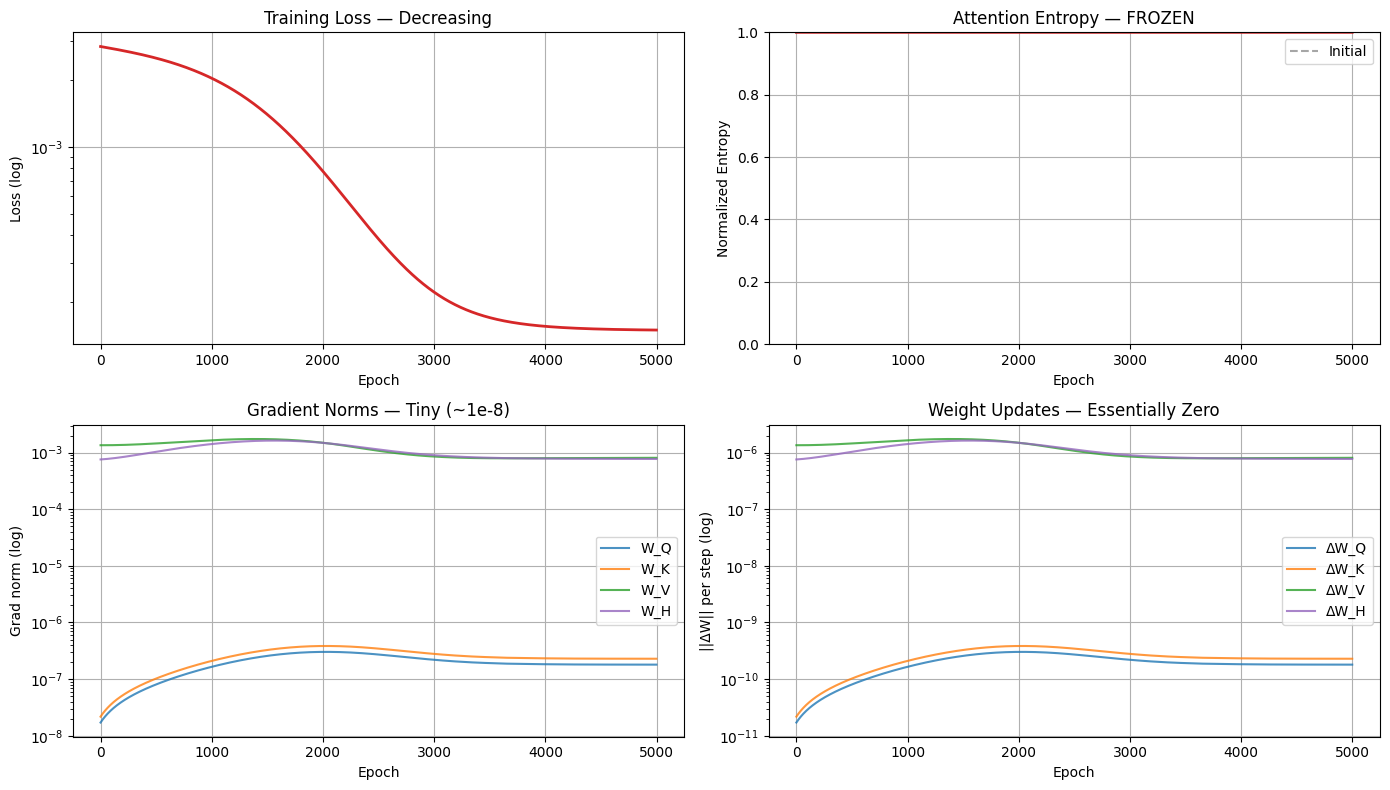

Grad norms ~1.7e-08, weight updates ~1.7e-11/step


In [27]:
# Loss, entropy, gradient norms, weight updates — all frozen
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(result_default["loss"], color="tab:red", linewidth=2)
axes[0, 0].set(yscale="log", xlabel="Epoch", ylabel="Loss (log)", title="Training Loss — Decreasing")
axes[0, 0].grid(True)

axes[0, 1].plot(result_default["entropy"], color="tab:red", linewidth=2)
axes[0, 1].axhline(y=result_default["entropy"][0], color="gray", linestyle="--", alpha=0.7, label="Initial")
axes[0, 1].set(xlabel="Epoch", ylabel="Normalized Entropy", ylim=(0, 1), title="Attention Entropy — FROZEN")
axes[0, 1].legend(); axes[0, 1].grid(True)

for wname, c in GRAD_COLORS.items():
    axes[1, 0].plot(result_default["grad"][wname], color=c, linewidth=1.5, label=wname, alpha=0.8)
axes[1, 0].set(yscale="log", xlabel="Epoch", ylabel="Grad norm (log)", title="Gradient Norms — Tiny (~1e-8)")
axes[1, 0].legend(); axes[1, 0].grid(True)

lr = result_default["cfg"]["lr"]
for wname, c in GRAD_COLORS.items():
    axes[1, 1].plot([lr * g for g in result_default["grad"][wname]], color=c, linewidth=1.5, label=f"Δ{wname}", alpha=0.8)
axes[1, 1].set(yscale="log", xlabel="Epoch", ylabel="||ΔW|| per step (log)", title="Weight Updates — Essentially Zero")
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout(); plt.show()
print(f"Grad norms ~{result_default['grad']['W_Q'][0]:.1e}, weight updates ~{lr * result_default['grad']['W_Q'][0]:.1e}/step")

### What's Going Wrong?

The loss is decreasing (slightly), so something is being learned. But the attention entropy stays constant — the model isn't learning to **focus** on the maximum element.

**Questions to investigate:**
1. Are the gradients too small to update the weights?
2. Is the learning rate too low?
3. Is there a scaling issue with our inputs?

Let's diagnose this systematically.

## 3.2 Diagnosing the Problem: Gradient Magnitude

Let's do a single forward-backward pass and examine the numbers.

In [28]:
# Setup
d_model = 8
init_scale = 0.1

rng = np.random.default_rng(0)
W_embed = init_scale * rng.standard_normal((1, d_model))
W_Q = init_scale * rng.standard_normal((d_model, d_model))
W_K = init_scale * rng.standard_normal((d_model, d_model))
W_V = init_scale * rng.standard_normal((d_model, d_model))
W_H = init_scale * rng.standard_normal((d_model, d_model))

# Sample input
x, y = generate_argmax_sample(dim=6, seed=1)
print(f"Input x:  {x}")
print(f"Target y: {y}")

Input x:  [5 8 9 5 0 0]
Target y: [9 9 9 9 9 9]


In [29]:
# With default scale=10.0
hidden_default, target_default = make_hidden_and_target(x, y, W_embed, scale=10.0)

print("=== With scale=10.0 (default) ===")
print(f"\nx (raw): {x}")
print(f"x / 10:  {x / 10.0}")
print(f"\nhidden_layer (first row): {hidden_default[0]}")
print(f"Activation magnitude: {np.linalg.norm(hidden_default):.6f}")

=== With scale=10.0 (default) ===

x (raw): [5 8 9 5 0 0]
x / 10:  [0.5 0.8 0.9 0.5 0.  0. ]

hidden_layer (first row): [ 0.00628651 -0.00660524  0.03202113  0.00524501 -0.02678347  0.01807975
  0.0652      0.04735405]
Activation magnitude: 0.260105


In [30]:
# One SGD step with scale=10.0
W_Q_new, W_K_new, W_V_new, W_H_new, loss, cache, grad_norms = attention_step(
    W_Q.copy(), W_K.copy(), W_V.copy(), W_H.copy(),
    hidden_default, target_default,
    lr=1e-3, clip=1.0
)

print("=== Gradient Analysis (scale=10.0) ===")
print(f"Loss: {loss:.6f}")
print(f"\nGradient norms:")
for k, v in grad_norms.items():
    print(f"  {k}: {v:.2e}")

print(f"\nWeight changes (ΔW = lr × grad):")
print(f"  ΔW_Q: {np.linalg.norm(W_Q_new - W_Q):.2e}")
print(f"  ΔW_K: {np.linalg.norm(W_K_new - W_K):.2e}")
print(f"  ΔW_V: {np.linalg.norm(W_V_new - W_V):.2e}")
print(f"  ΔW_H: {np.linalg.norm(W_H_new - W_H):.2e}")

=== Gradient Analysis (scale=10.0) ===
Loss: 0.003496

Gradient norms:
  W_Q: 1.52e-09
  W_K: 1.85e-09
  W_V: 1.37e-03
  W_H: 1.18e-03

Weight changes (ΔW = lr × grad):
  ΔW_Q: 1.52e-12
  ΔW_K: 1.85e-12
  ΔW_V: 1.37e-06
  ΔW_H: 1.18e-06


In [31]:
# Instrument: what changes gradients vs what changes updates?
#
# Key distinction:
# - The gradient ∇W is a property of (W, data) at the current point.
# - The learning rate `lr` does NOT change ∇W; it scales the update:  ΔW = -lr * ∇W.
# - Across *epochs*, a different lr moves W to different places, so later gradients can differ.
#
# Also: in THIS assignment, `scale` is a DIVISOR (we use x/scale). So smaller scale => larger activations.

print("=== Scale sanity check (hidden norm vs scale) ===")
for s in [10.0, 5.0, 2.0, 1.0]:
    h_s, t_s = make_hidden_and_target(x, y, W_embed, scale=s)
    print(f"scale={s:>4}: ||hidden||={np.linalg.norm(h_s):.3e}, ||target||={np.linalg.norm(t_s):.3e}")

print("\n=== LR sanity check (gradients at a fixed point) ===")
clip_demo = 1e9  # effectively no clipping, so ΔW scales cleanly with lr
lrs = [1e-3, 1e-2, 1e-1]
base = None

for lr_test in lrs:
    W_Q_new, W_K_new, W_V_new, W_H_new, loss_lr, cache_lr, grad_lr = attention_step(
        W_Q.copy(), W_K.copy(), W_V.copy(), W_H.copy(),
        hidden_default, target_default,
        lr=lr_test, clip=clip_demo
    )

    dWQ = float(np.linalg.norm(W_Q_new - W_Q))

    if base is None:
        base = grad_lr
        ref_lr = lr_test

    print(
        f"lr={lr_test:.0e}: "
        f"||∇W_Q||={grad_lr['W_Q']:.3e} (Δ vs lr={ref_lr:.0e}: {abs(grad_lr['W_Q']-base['W_Q']):.3e}), "
        f"||ΔW_Q||={dWQ:.3e}, ||ΔW_Q||/lr={dWQ/lr_test:.3e}"
    )


=== Scale sanity check (hidden norm vs scale) ===
scale=10.0: ||hidden||=2.601e-01, ||target||=4.106e-01
scale= 5.0: ||hidden||=5.202e-01, ||target||=8.213e-01
scale= 2.0: ||hidden||=1.301e+00, ||target||=2.053e+00
scale= 1.0: ||hidden||=2.601e+00, ||target||=4.106e+00

=== LR sanity check (gradients at a fixed point) ===
lr=1e-03: ||∇W_Q||=1.519e-09 (Δ vs lr=1e-03: 0.000e+00), ||ΔW_Q||=1.519e-12, ||ΔW_Q||/lr=1.519e-09
lr=1e-02: ||∇W_Q||=1.519e-09 (Δ vs lr=1e-03: 0.000e+00), ||ΔW_Q||=1.519e-11, ||ΔW_Q||/lr=1.519e-09
lr=1e-01: ||∇W_Q||=1.519e-09 (Δ vs lr=1e-03: 0.000e+00), ||ΔW_Q||=1.519e-10, ||ΔW_Q||/lr=1.519e-09


### The Problem

With `scale=10.0`:
- Inputs are divided by 10 before embedding
- Activations are ~0.0–0.9 instead of ~0–9
- Gradient norms are **~1e-8** (tiny!)
- Weight changes are **~1e-11** per step

$$
\Delta W = \text{lr} \times \nabla W \approx 10^{-3} \times 10^{-8} = 10^{-11}
$$

**That's essentially zero!** The weights don't move.

## 3.3 The Fix: Boosting Gradient Signal

We have three knobs to increase gradient magnitude:

| Parameter | Effect | Recommended Change |
|-----------|--------|-------------------|
| `scale` | Smaller scale → larger activations → larger gradients | 10.0 → **1.0** |
| `lr` | Larger lr → bigger weight updates | 1e-3 → **1e-2** |
| `clip` | Larger clip → allows bigger gradient components | 1.0 → **10.0** |

In [44]:
# With scale=1.0 (fix)
hidden_fixed, target_fixed = make_hidden_and_target(x, y, W_embed, scale=1.0)

print("=== With scale=1.0 (FIXED) ===")
print(f"\nx (raw): {x}")
print(f"x / 1:   {x / 1.0}  (no shrinking!)")
print(f"\nhidden_layer (first row): {hidden_fixed[0]}")
print(f"Activation magnitude: {np.linalg.norm(hidden_fixed):.6f}")

=== With scale=1.0 (FIXED) ===

x (raw): [5 8 9 5 0 0]
x / 1:   [5. 8. 9. 5. 0. 0.]  (no shrinking!)

hidden_layer (first row): [ 0.06286511 -0.06605243  0.32021133  0.05245006 -0.26783469  0.18079753
  0.65200002  0.47354048]
Activation magnitude: 2.601053


In [45]:
# One SGD step with boosted parameters
W_Q_new, W_K_new, W_V_new, W_H_new, loss, cache, grad_norms = attention_step(
    W_Q.copy(), W_K.copy(), W_V.copy(), W_H.copy(),
    hidden_fixed, target_fixed,
    lr=1e-2,   # 10x learning rate
    clip=10.0  # 10x clip threshold
)

print("=== Gradient Analysis (scale=1.0, lr=1e-2, clip=10.0) ===")
print(f"Loss: {loss:.6f}")
print(f"\nGradient norms:")
for k, v in grad_norms.items():
    print(f"  {k}: {v:.2e}")

print(f"\nWeight changes (ΔW = lr × grad):")
print(f"  ΔW_Q: {np.linalg.norm(W_Q_new - W_Q):.2e}")
print(f"  ΔW_K: {np.linalg.norm(W_K_new - W_K):.2e}")
print(f"  ΔW_V: {np.linalg.norm(W_V_new - W_V):.2e}")
print(f"  ΔW_H: {np.linalg.norm(W_H_new - W_H):.2e}")

=== Gradient Analysis (scale=1.0, lr=1e-2, clip=10.0) ===
Loss: 0.349563

Gradient norms:
  W_Q: 1.53e-05
  W_K: 1.87e-05
  W_V: 1.37e-01
  W_H: 1.18e-01

Weight changes (ΔW = lr × grad):
  ΔW_Q: 1.53e-07
  ΔW_K: 1.87e-07
  ΔW_V: 1.37e-03
  ΔW_H: 1.18e-03


### Now We Have Real Updates!

- Gradient norms: **~1e-1** (not 1e-8)
- Weight changes: **~1e-2** (not 1e-11)

That's a **billion times larger**! Now the model can actually learn.

## 3.4 Normalized Entropy

To compare entropy across different sequence lengths (2–8), we normalize to [0, 1]:

$$
H_{\text{norm}} = \frac{H}{\log(n)}
$$

Where:
- $H_{\text{norm}} = 0$ → perfectly sharp (one-hot)
- $H_{\text{norm}} = 1$ → uniform distribution

In [46]:
# Test
print("Entropy of current attention matrix:")
print(f"  Raw: {attention_row_entropy(cache['A']):.4f}")
print(f"  Normalized: {attention_row_entropy_normalized(cache['A']):.4f}")

Entropy of current attention matrix:
  Raw: 1.7918
  Normalized: 1.0000


## 3.5 Training Comparison: Default vs Boosted

Now let's train and see the entropy actually evolve.

In [35]:
# Train both configs with deep diagnostics (10k epochs)
configs = {
    "default (scale=10, lr=1e-3)": {"scale": 10.0, "lr": 1e-3, "clip": 1.0},
    "boosted (scale=1, lr=1e-2)":  {"scale": 1.0,  "lr": 1e-2, "clip": 10.0},
}

results = {}
for name, cfg in configs.items():
    print(f"\n{name}:")
    results[name] = train_attention_model(
        train_set, scale=cfg["scale"], lr=cfg["lr"], clip=cfg["clip"],
        epochs=10000, track_diagnostics=True, diagnostic_freq=1000,
    )
    r = results[name]
    print(f"  Final loss: {r['loss'][-1]:.6f}, entropy: {r['entropy'][-1]:.4f}")


default (scale=10, lr=1e-3):
  Epoch  1000: loss=0.002039, entropy=1.0000
  Epoch  2000: loss=0.000776, entropy=1.0000
  Epoch  3000: loss=0.000221, entropy=1.0000
  Epoch  4000: loss=0.000155, entropy=1.0000
  Epoch  5000: loss=0.000149, entropy=1.0000
  Epoch  6000: loss=0.000148, entropy=1.0000
  Epoch  7000: loss=0.000148, entropy=1.0000
  Epoch  8000: loss=0.000148, entropy=1.0000
  Epoch  9000: loss=0.000148, entropy=1.0000
  Epoch 10000: loss=0.000148, entropy=1.0000
  Final loss: 0.000148, entropy: 1.0000

boosted (scale=1, lr=1e-2):
  Epoch  1000: loss=0.011109, entropy=0.9138
  Epoch  2000: loss=0.009201, entropy=0.6733
  Epoch  3000: loss=0.007739, entropy=0.4812
  Epoch  4000: loss=0.007328, entropy=0.4082
  Epoch  5000: loss=0.007163, entropy=0.3720
  Epoch  6000: loss=0.007081, entropy=0.3505
  Epoch  7000: loss=0.007033, entropy=0.3362
  Epoch  8000: loss=0.007003, entropy=0.3259
  Epoch  9000: loss=0.006982, entropy=0.3181
  Epoch 10000: loss=0.006967, entropy=0.3119
 

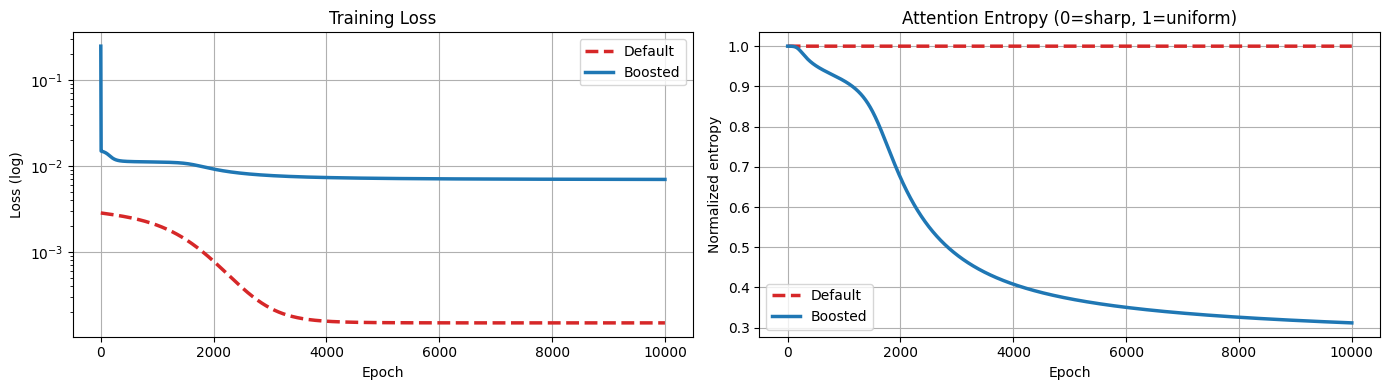

In [36]:
# Loss and entropy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in results.items():
    s = STYLES[name]
    axes[0].plot(res["loss"], s["ls"], color=s["color"], linewidth=2.5, label=s["label"])
    axes[1].plot(res["entropy"], s["ls"], color=s["color"], linewidth=2.5, label=s["label"])
axes[0].set(yscale="log", xlabel="Epoch", ylabel="Loss (log)", title="Training Loss")
axes[0].legend(); axes[0].grid(True)
axes[1].set(xlabel="Epoch", ylabel="Normalized entropy", title="Attention Entropy (0=sharp, 1=uniform)")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

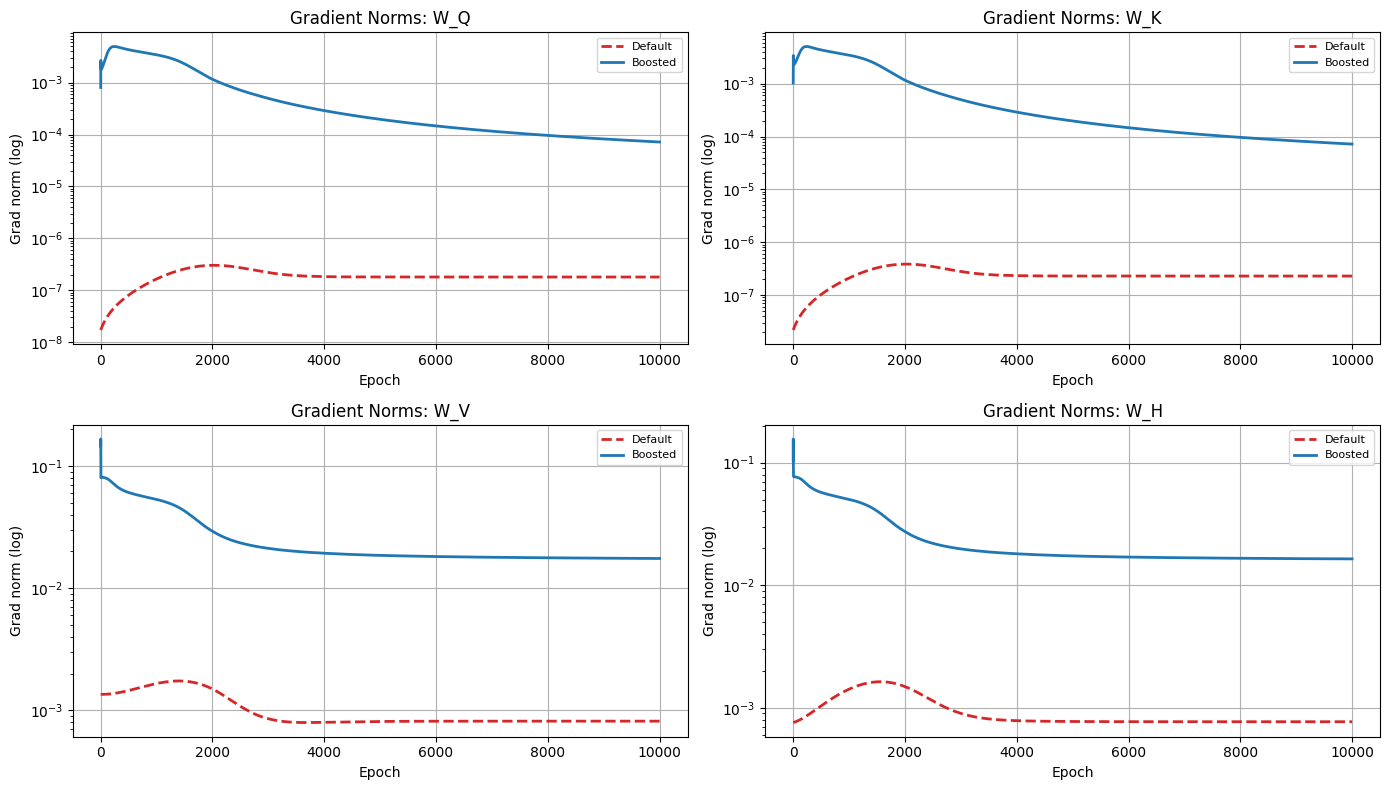

In [37]:
# Gradient norms per weight matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
    ax = axes[idx // 2][idx % 2]
    for name, res in results.items():
        s = STYLES[name]
        ax.plot(res["grad"][wname], s["ls"], color=s["color"], linewidth=2, label=s["label"])
    ax.set(yscale="log", xlabel="Epoch", ylabel="Grad norm (log)", title=f"Gradient Norms: {wname}")
    ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

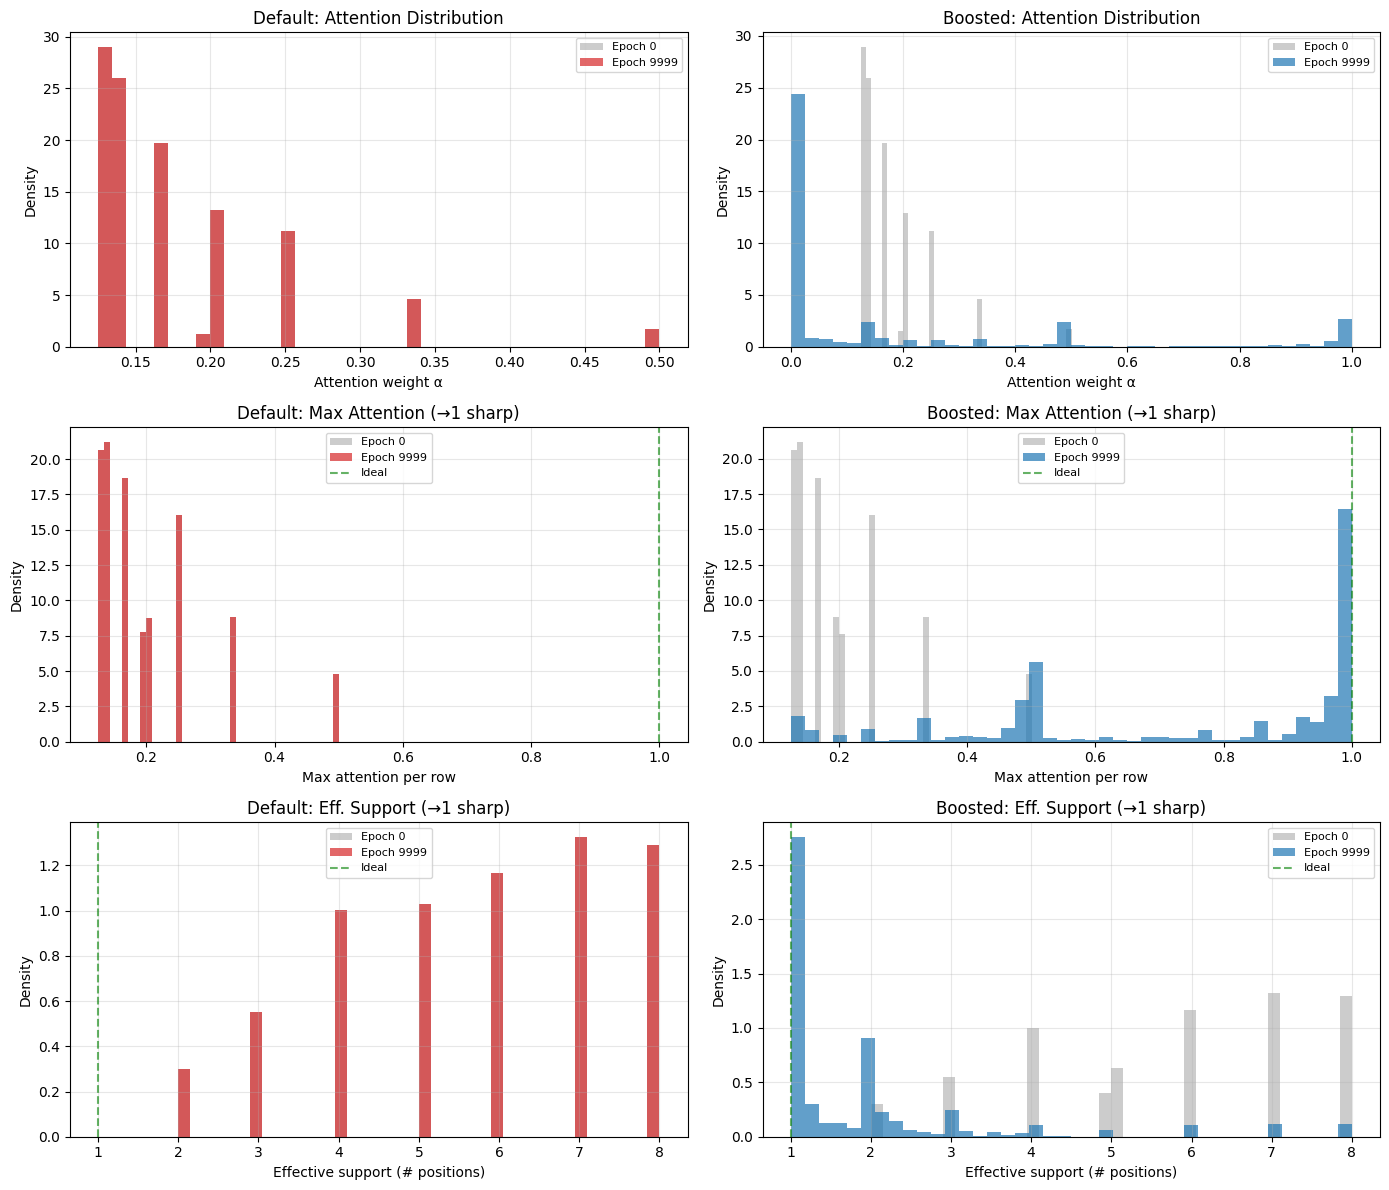

In [38]:
# Attention histograms: before vs after for each config
plot_histograms_comparison(results)

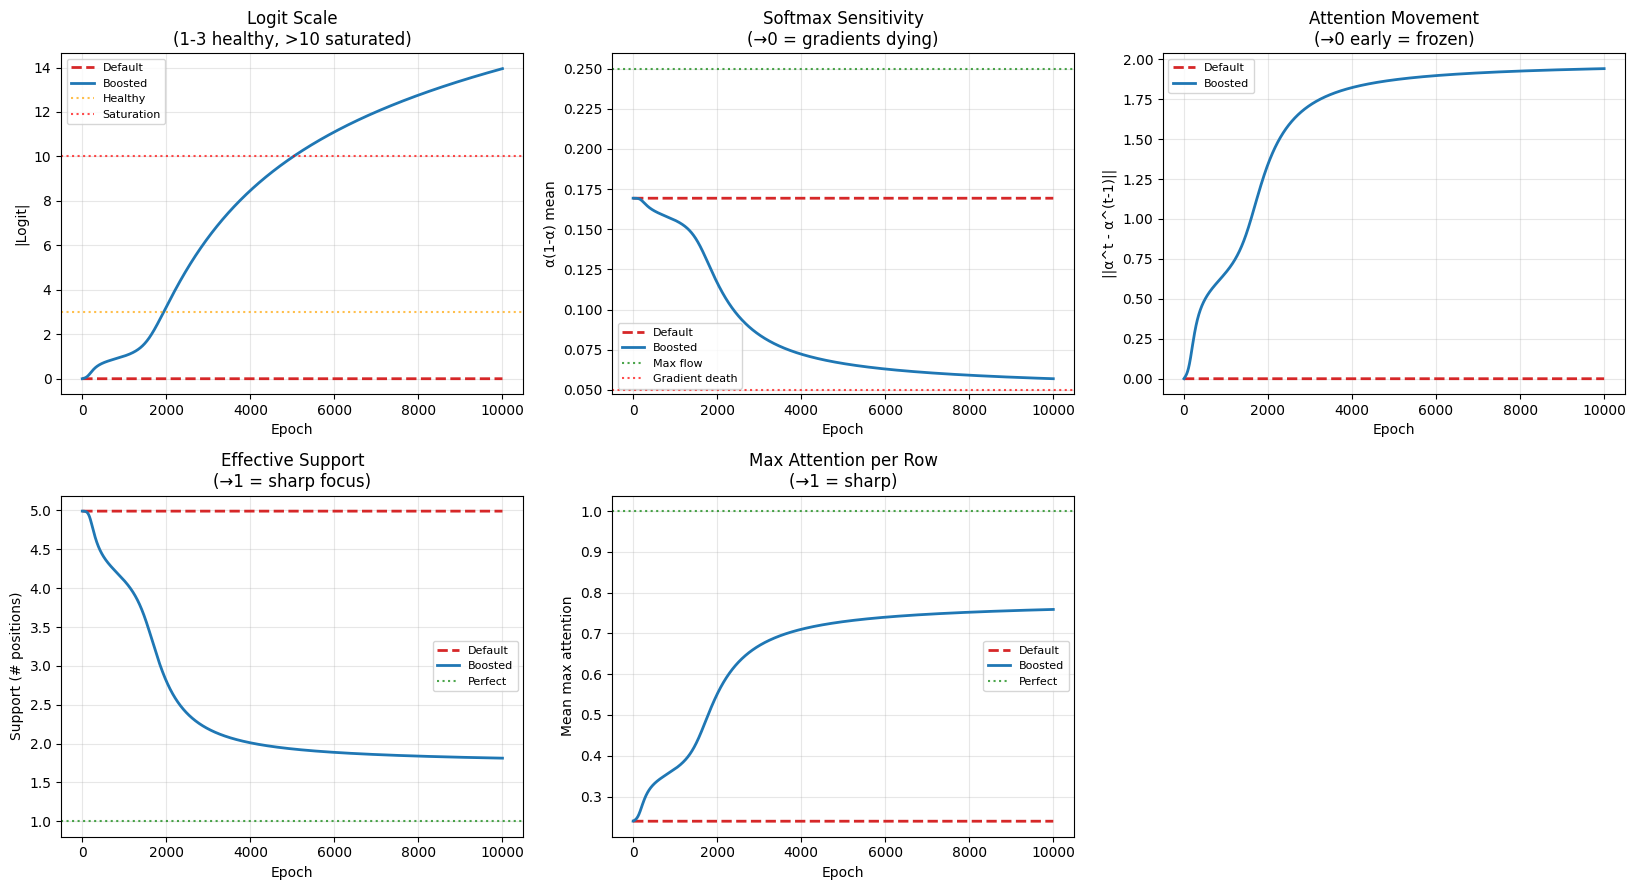

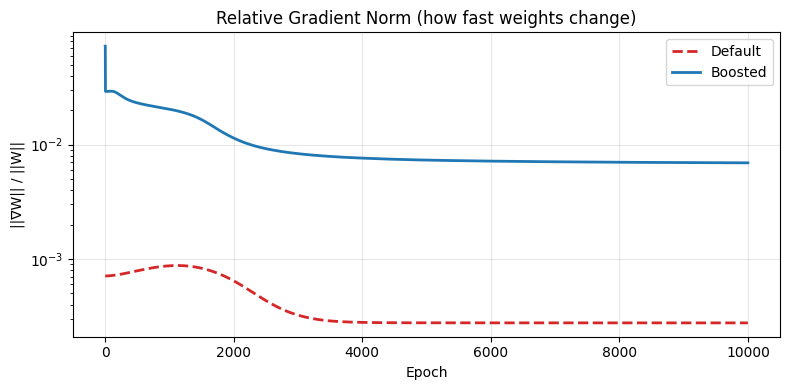

In [39]:
# Deep diagnostics: 6 signals that reveal whether attention is actually learning
plot_diagnostic_comparison(results, [
    ("logit_abs_mean", "Logit Scale\n(1-3 healthy, >10 saturated)", "|Logit|",
     [(3, "orange", "Healthy"), (10, "red", "Saturation")]),
    ("sensitivity_mean", "Softmax Sensitivity\n(→0 = gradients dying)", "α(1-α) mean",
     [(0.25, "green", "Max flow"), (0.05, "red", "Gradient death")]),
    ("movement", "Attention Movement\n(→0 early = frozen)", "||α^t - α^(t-1)||", []),
    ("support_mean", "Effective Support\n(→1 = sharp focus)", "Support (# positions)",
     [(1.0, "green", "Perfect")]),
    ("max_mean", "Max Attention per Row\n(→1 = sharp)", "Mean max attention",
     [(1.0, "green", "Perfect")]),
])

# Relative gradient norms (averaged across all weight matrices)
fig, ax = plt.subplots(figsize=(8, 4))
for name, res in results.items():
    diag = res["diagnostics"]
    if not diag:
        continue
    s = STYLES[name]
    epochs = diag["epochs"]
    rel_avg = [np.mean([diag["grad_relative"][k][i] for k in ["W_Q", "W_K", "W_V", "W_H"]])
               for i in range(len(epochs))]
    ax.plot(epochs, rel_avg, s["ls"], color=s["color"], linewidth=2, label=s["label"])
ax.set(xlabel="Epoch", ylabel="||∇W|| / ||W||", yscale="log",
       title="Relative Gradient Norm (how fast weights change)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Diagnostic Signals Reference

| Signal | What It Measures | Healthy Range | Warning Signs |
|--------|-----------------|---------------|---------------|
| **Logit Scale** | Pre-softmax magnitude $\|QK^T/\sqrt{d_k}\|$ | 1-5 | < 0.5 (too flat) or > 10 (saturated) |
| **Softmax Sensitivity** | $\alpha(1-\alpha)$ | 0.1-0.25 early | → 0 = gradients dying |
| **Attention Movement** | $\|\alpha^t - \alpha^{t-1}\|$ | Gradual decrease | → 0 early = frozen |
| **Effective Support** | $1/\sum \alpha^2$ | Decreasing toward 1 | Stuck high = diffuse |
| **Max Attention** | $\max_j \alpha_{ij}$ | Increasing toward 1 | Stuck at 1/n = uniform |
| **Relative Gradient** | $\|\nabla W\| / \|W\|$ | > 1e-4 | < 1e-6 = weight frozen |

**Key insight:** If loss decreases but attention movement → 0 while V/H gradients stay active, the model is **learning around attention, not through it**.

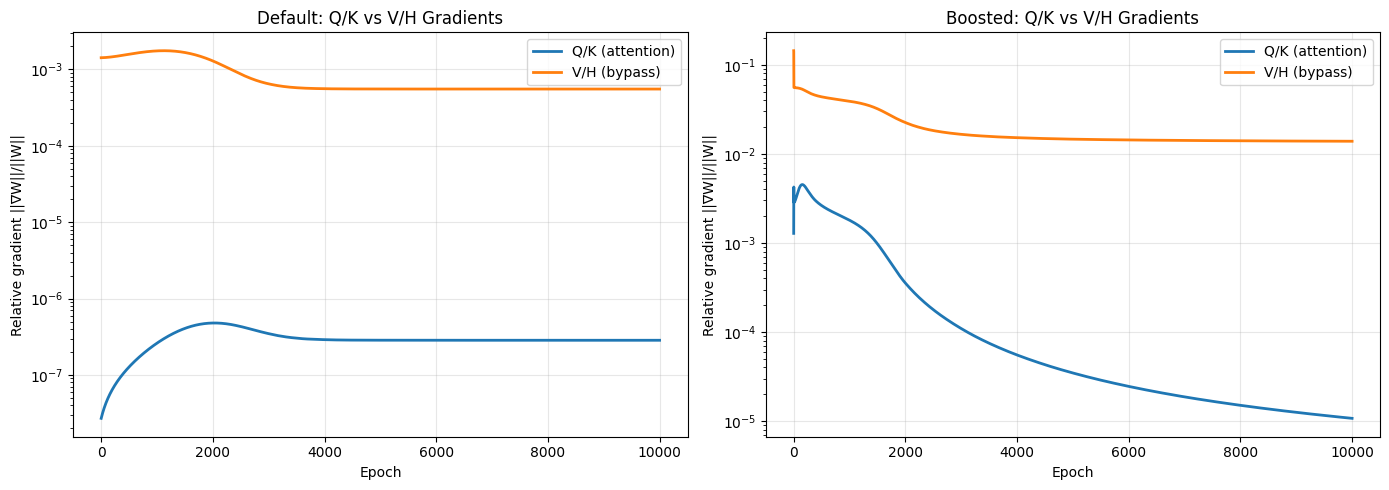

Default: V/H doing 1942x more learning — attention is frozen, model learning AROUND it.


In [40]:
# Q/K vs V/H gradient analysis — are Q/K frozen while V/H compensate?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, name in enumerate(list(results.keys())):
    diag = results[name]["diagnostics"]
    epochs = diag["epochs"]
    qk = [(diag["grad_relative"]["W_Q"][i] + diag["grad_relative"]["W_K"][i]) / 2 for i in range(len(epochs))]
    vh = [(diag["grad_relative"]["W_V"][i] + diag["grad_relative"]["W_H"][i]) / 2 for i in range(len(epochs))]
    axes[col].plot(epochs, qk, color="tab:blue", linewidth=2, label="Q/K (attention)")
    axes[col].plot(epochs, vh, color="tab:orange", linewidth=2, label="V/H (bypass)")
    axes[col].set(xlabel="Epoch", ylabel="Relative gradient ||∇W||/||W||", yscale="log",
                  title=f"{STYLES[name]['label']}: Q/K vs V/H Gradients")
    axes[col].legend(); axes[col].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Print diagnosis
for name in results:
    diag = results[name]["diagnostics"]
    qk_f = (diag["grad_relative"]["W_Q"][-1] + diag["grad_relative"]["W_K"][-1]) / 2
    vh_f = (diag["grad_relative"]["W_V"][-1] + diag["grad_relative"]["W_H"][-1]) / 2
    ratio = vh_f / (qk_f + 1e-12)
    label = STYLES[name]["label"]
    if ratio > 100 and qk_f < 1e-6:
        print(f"{label}: V/H doing {ratio:.0f}x more learning — attention is frozen, model learning AROUND it.")
    elif qk_f > 1e-4:
        print(f"{label}: Q/K gradients healthy ({qk_f:.2e}). Attention IS learning.")

### 3.5.1 Test Set Evaluation

Now let's see how these models perform on **unseen data**. This is the true test of whether the model learned the argmax task.

In [41]:
# Test set evaluation (evaluate_model is defined in the functions cell)
print(f"{'Config':<35} {'Accuracy':>10} {'Entropy':>10} {'Attn on Max':>12} {'Test Loss':>12}")
print("-" * 82)
for name, res in results.items():
    ev = evaluate_model(res, test_set)
    label = STYLES[name]["label"]
    print(f"{label:<35} {ev['accuracy']:>9.1%} {ev['test_entropy']:>10.3f} {ev['attention_on_max']:>11.1%} {ev['test_loss']:>12.6f}")

Config                                Accuracy    Entropy  Attn on Max    Test Loss
----------------------------------------------------------------------------------
Default                                  0.0%      1.000       24.4%     0.000134
Boosted                                 98.3%      0.362       72.2%     0.007261


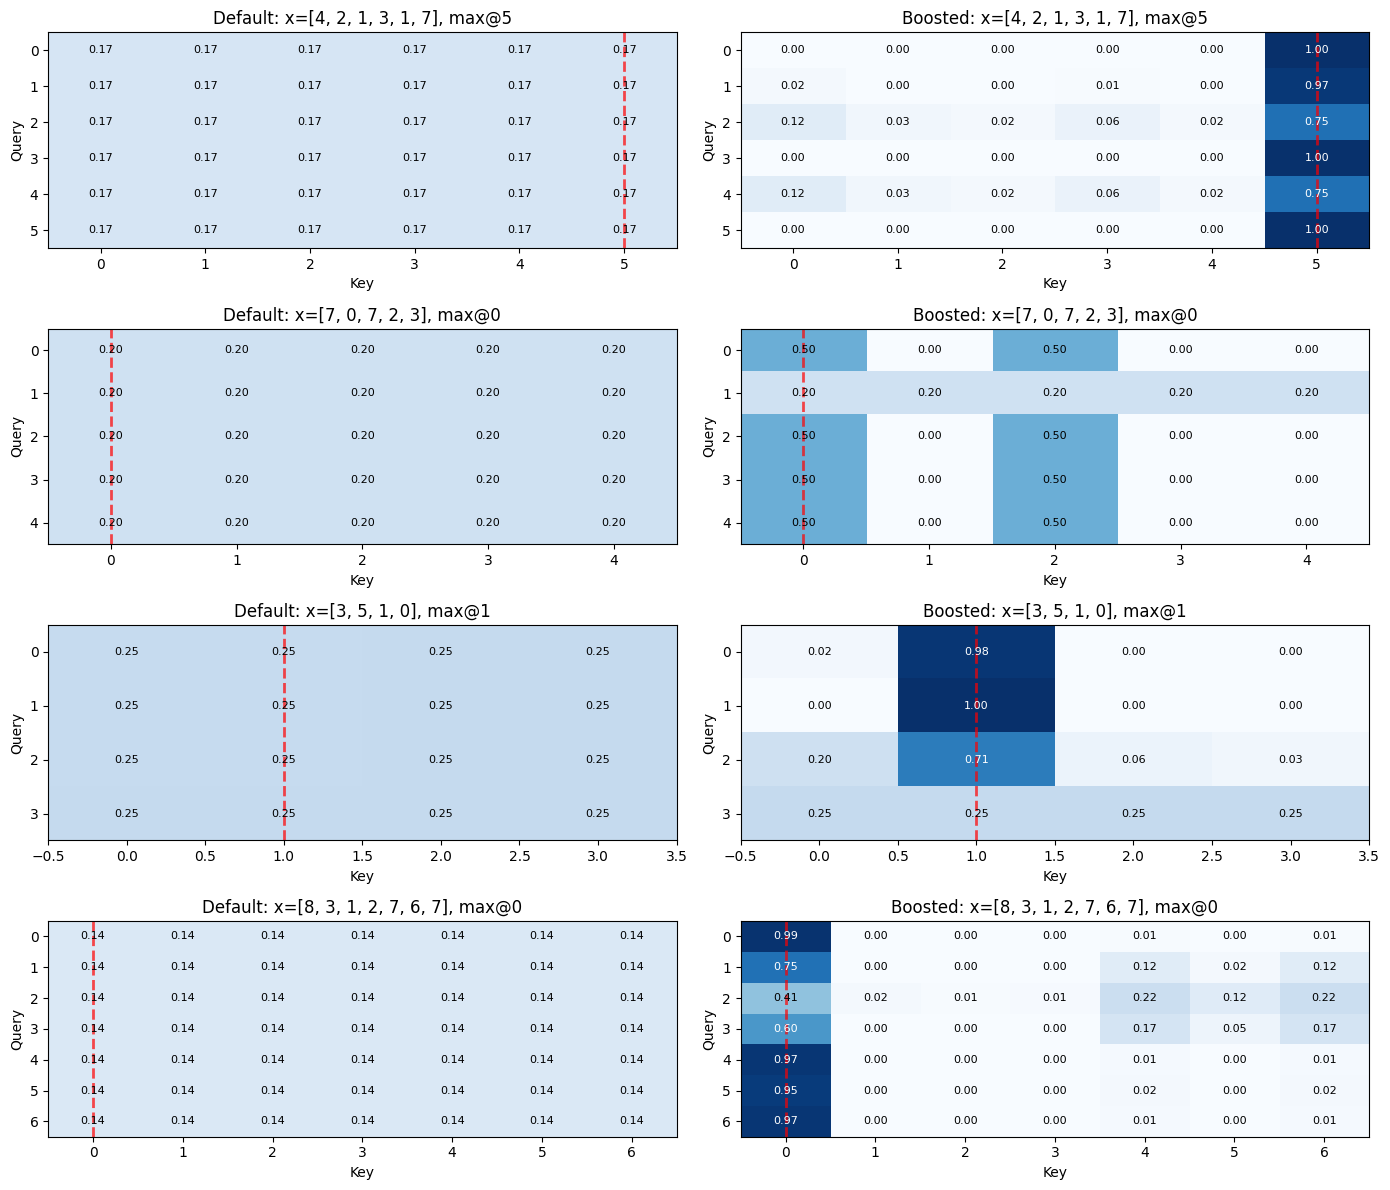

Red dashed line = max element position. Boosted should concentrate there.


In [42]:
# Attention heatmaps: default vs boosted on representative test examples
rep_idxs = pick_representative_indices(test_set, want=4)
plot_attention_heatmaps(results, test_set, rep_idxs)
print("Red dashed line = max element position. Boosted should concentrate there.")

In [43]:
# Detailed predictions on a few test examples
for idx in rep_idxs[:3]:
    x_raw, y_raw = test_set[idx]
    max_pos, max_val = int(np.argmax(x_raw)), int(np.max(x_raw))
    print(f"\nx={x_raw.tolist()}, max={max_val}@{max_pos}, target={y_raw.tolist()}")
    for name, res in results.items():
        _, cache, y_dec = forward_from_result(res, x_raw, y_raw)
        pred_pos = np.argmax(y_dec)
        label = STYLES[name]["label"]
        status = "correct" if pred_pos == max_pos else "WRONG"
        print(f"  {label:>8}: pred={np.round(y_dec, 2)}, argmax@{pred_pos} ({status}), "
              f"attn on max={np.mean(cache['A'][:, max_pos]):.1%}")


x=[4, 2, 1, 3, 1, 7], max=7@5, target=[7, 7, 7, 7, 7, 7]
   Default: pred=[4.75 4.75 4.75 4.75 4.75 4.75], argmax@2 (WRONG), attn on max=16.7%
   Boosted: pred=[7.21 7.1  6.2  7.2  6.2  7.21], argmax@5 (correct), attn on max=91.1%

x=[7, 0, 7, 2, 3], max=7@0, target=[7, 7, 7, 7, 7]
   Default: pred=[6.01 6.01 6.01 6.01 6.01], argmax@1 (WRONG), attn on max=20.0%
   Boosted: pred=[7.21 3.92 7.21 7.19 7.21], argmax@0 (correct), attn on max=44.0%

x=[3, 5, 1, 0], max=5@1, target=[5, 5, 5, 5]
   Default: pred=[3.56 3.56 3.56 3.56], argmax@3 (WRONG), attn on max=25.0%
   Boosted: pred=[5.1  5.15 4.33 2.32], argmax@1 (correct), attn on max=73.2%


### Key Takeaways from Test Evaluation

| Metric | Default Config | Boosted Config | What It Tells Us |
|--------|---------------|----------------|------------------|
| **Accuracy** | ~Random | High | Model can identify max position |
| **Entropy** | ~1.0 (uniform) | Low (~0.2-0.4) | Attention learned to focus |
| **Attn on Max** | ~1/L (random) | High (>50%) | Attention points to correct position |
| **Test Loss** | High | Low | Embedding predictions are accurate |

**The boosted config succeeds because:**
1. Larger activations (scale=1.0) → larger gradients
2. Higher learning rate (lr=1e-2) → bigger weight updates
3. Higher clip threshold (clip=10.0) → gradients aren't truncated

**This is the fundamental lesson:** Training neural networks requires sufficient gradient flow. Without it, weights don't update and the model can't learn.

---

## 3.6 Summary: Parameter Tuning Guide

### The Core Issue

Neural network training requires **gradient flow**. If gradients are too small, weights don't update and nothing is learned.

### Parameters That Control Gradient / Update Magnitude

| Parameter | What It Does | What You'll Observe |
|-----------|--------------|---------------------|
| `scale` | Divides inputs before embedding (`x/scale`) | Lower `scale` → **larger activations** → typically **larger gradients** |
| `lr` | Scales the update step $\Delta W = -\text{lr}\,\nabla W$ | At a fixed point, `lr` **does not change** $\nabla W$, but larger `lr` makes **bigger updates** (and can change later gradients indirectly) |
| `clip` | Clips gradients before applying updates | Raw gradients are the same, but the **applied** update is capped when clipping triggers |
| `init_scale` | Std of initial weights | Changes activation magnitudes at initialization (can affect early gradient scale) |

### Diagnostic Signals to Monitor

Beyond gradient norms, instrument the **geometry of attention**:

| Signal | Formula | Healthy | Frozen |
|--------|---------|---------|--------|
| **Entropy** | $-\sum \alpha \log \alpha$ | Decreasing | Flat |
| **Max Attention** | $\max_j \alpha_{ij}$ | → 1.0 | Stuck at 1/n |
| **Effective Support** | $1/\sum \alpha^2$ | → 1.0 | Stays high |
| **Logit Scale** | $\|QK^T/\sqrt{d_k}\|$ | 1-5 | < 0.5 |
| **Softmax Sensitivity** | $\alpha(1-\alpha)$ | 0.1-0.25 → lower | Stuck ~0.25 |
| **Attention Movement** | $\|\alpha^t - \alpha^{t-1}\|$ | Gradual → 0 | Immediate → 0 |
| **Q/K vs V/H Gradients** | Ratio | ~1x | V/H >> Q/K |

### Three Failure Patterns

1. **Obvious:** Gradients ~0, loss flat → Scale/LR too small
2. **Subtle:** Loss ↓, entropy flat → Q/K frozen, V/H compensating  
3. **Dangerous:** Entropy ↓ fast, sensitivity → 0 → Forced sharpness, not learned

### Recommended Fix

```python
# Default (too weak)
scale=10.0, lr=1e-3, clip=1.0

# Fixed (real gradient flow)
scale=1.0, lr=1e-2, clip=10.0
```

### Debugging Checklist

1. **Print gradient norms** after the first step (< 1e-6 = vanishing)
2. **Check logit scale** (< 0.5 = softmax too flat)
3. **Track attention movement** (→ 0 early = frozen)
4. **Compare Q/K vs V/H gradients** (V/H >> Q/K = bypassing attention)
5. **Histogram attention weights** (should shift from uniform to sparse)

---

## Next: Part 4 — Experiments

With proper gradient flow established, we can now run controlled experiments:
- **Experiment A:** Temperature scaling ($\alpha$)
- **Experiment B:** Split learning rates (Q/K vs V/H)